En este trabajo se estudia el problema de contorno dado por:
		$$T''(x)-\sigma^2 T(x)=-f(x) \ , \ 0<x<L$$
		$$T'(0)=\beta T(0)-\gamma $$
		$$T(L)=\delta $$
		$$f(x)=F_0 e^{-\mu x}$$
En primer lugar se hallará su solución analítica y, a continuación, se propondrán dos esquemas de diferencias finitas de segundo orden, ambos simétricos: nodo fantasma y derivada asimétrica

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


   MUESTRA DE VALORES EN ALGUNOS NODOS COINCIDENTES
x = 0.0  | Analítica: 1.41559  | Fantasma: 1.41566  | Unilateral: 1.41543
x = 0.25 | Analítica: 1.72497  | Fantasma: 1.725    | Unilateral: 1.72487
x = 0.5  | Analítica: 1.97511  | Fantasma: 1.97513  | Unilateral: 1.97506
x = 0.75 | Analítica: 2.34036  | Fantasma: 2.34037  | Unilateral: 2.34034
x = 1.0  | Analítica: 3.0      | Fantasma: 3.0      | Unilateral: 3.0


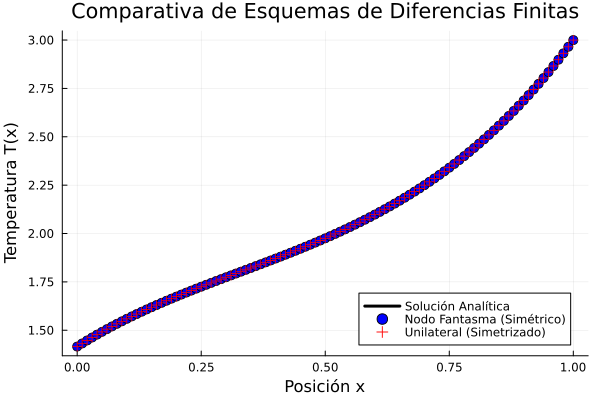

In [6]:
# ==========================================
# PREPARACIÓN DEL ENTORNO
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using LinearAlgebra
using Plots

# Encapsulamos todo en una función para evitar el aviso de redefinición de constantes globales
function ejecutar_simulacion()
    # 1. PARÁMETROS DEL PROBLEMA (Ahora locales, sin 'const')
    L = 1.0        # Longitud del dominio
    σ = 2.0        # Parámetro sigma
    β = 1.5        # Parámetro beta (Robin)
    γ = 0.5        # Parámetro gamma (Robin)
    δ = 3.0        # Condición Dirichlet en x=L
    F0 = 10.0      # Amplitud del término fuente
    μ = 1.0        # Exponente del término fuente

    # Discretización
    N = 100         
    dx = L / N
    x_nodos = collect(0:dx:L)

    # ==========================================
    # 2. SOLUCIÓN ANALÍTICA
    # ==========================================
    function solucion_analitica(x)
        A = δ - (F0 / (σ^2 - μ^2)) * exp(-μ * L)
        num_B = γ + ((β + μ) * F0) / (μ^2 - σ^2) - (σ * sinh(σ * L) + β * cosh(σ * L)) * A
        den_B = σ * cosh(σ * L) + β * sinh(σ * L)
        B = num_B / den_B
        return A * cosh(σ * (L - x)) + B * sinh(σ * (L - x)) + (F0 / (σ^2 - μ^2)) * exp(-μ * x)
    end

    y_analitica = solucion_analitica.(x_nodos)

    # ==========================================
    # 3. MÉTODO 1: NODO FANTASMA
    # ==========================================
    function resolver_nodo_fantasma()
        A_mat = zeros(N, N)
        b = zeros(N)
        f = [F0 * exp(-μ * i * dx) for i in 0:N-1]
        
        A_mat[1, 1] = -(1/dx^2 + β/dx + σ^2/2)
        A_mat[1, 2] = 1/dx^2
        b[1] = -f[1]/2 - γ/dx
        
        for i in 2:N-1
            A_mat[i, i-1] = 1/dx^2
            A_mat[i, i]   = -(2/dx^2 + σ^2)
            A_mat[i, i+1] = 1/dx^2
            b[i]      = -f[i]
        end
        
        A_mat[N, N-1] = 1/dx^2
        A_mat[N, N]   = -(2/dx^2 + σ^2)
        b[N]      = -f[N] - δ/dx^2
        
        A_sym = SymTridiagonal(diag(A_mat), diag(A_mat, 1))
        T_interior = A_sym \ b
        return [T_interior; δ]
    end

    y_fantasma = resolver_nodo_fantasma()

    # ==========================================
    # 4. MÉTODO 2: ESQUEMA UNILATERAL SIMETRIZADO
    # ==========================================
    function resolver_unilateral()
        M = N - 1
        A_mat = zeros(M, M)
        b = zeros(M)
        f = [F0 * exp(-μ * i * dx) for i in 1:N-1]
        
        ω = (3 + 2*β*dx) / (2 + 2*β*dx)
        
        A_mat[1, 1] = -( (1/dx^2) * ((2 + 4*β*dx) / (3 + 2*β*dx)) + σ^2 ) * ω
        A_mat[1, 2] = 1/dx^2
        b[1] = -(f[1] + (2*γ) / (dx * (3 + 2*β*dx))) * ω
        
        for i in 2:M-1
            A_mat[i, i-1] = 1/dx^2
            A_mat[i, i]   = -(2/dx^2 + σ^2)
            A_mat[i, i+1] = 1/dx^2
            b[i]      = -f[i]
        end
        
        A_mat[M, M-1] = 1/dx^2
        A_mat[M, M]   = -(2/dx^2 + σ^2)
        b[M]      = -f[M] - δ/dx^2
        
        A_sym = SymTridiagonal(diag(A_mat), diag(A_mat, 1))
        T_interior = A_sym \ b
        
        T1 = T_interior[1]
        T2 = T_interior[2]
        T0 = (4*T1 - T2 + 2*γ*dx) / (3 + 2*β*dx)
        
        return [T0; T_interior; δ]
    end

    y_unilateral = resolver_unilateral()

    # ==========================================
    # 5. IMPRESIÓN DE RESULTADOS
    # ==========================================
    println("="^65)
    println("   MUESTRA DE VALORES EN ALGUNOS NODOS COINCIDENTES")
    println("="^65)
    
    indices_muestra = [1, div(N, 4) + 1, div(N, 2) + 1, div(3*N, 4) + 1, N + 1]
    for idx in indices_muestra
        println(
            "x = $(rpad(round(x_nodos[idx], digits=2), 4)) | "*
            "Analítica: $(rpad(round(y_analitica[idx], digits=5), 8)) | "*
            "Fantasma: $(rpad(round(y_fantasma[idx], digits=5), 8)) | "*
            "Unilateral: $(round(y_unilateral[idx], digits=5))"
        )
    end
    println("="^65)

    # Gráfico
    p = plot(title="Comparativa de Esquemas de Diferencias Finitas", xlabel="Posición x", ylabel="Temperatura T(x)", legend=:bottomright)
    plot!(p, x_nodos, y_analitica, label="Solución Analítica", linewidth=3, linecolor=:black)
    scatter!(p, x_nodos, y_fantasma, label="Nodo Fantasma (Simétrico)", markershape=:circle, markersize=5, markercolor=:blue)
    scatter!(p, x_nodos, y_unilateral, label="Unilateral (Simetrizado)", markershape=:cross, markersize=5, markercolor=:red)
    
    display(p)
end

# Ejecutamos la simulación
ejecutar_simulacion()